# Analisis Error NER per Kelompok Eksperimen

Visualisasi & perbandingan kesalahan prediksi model NER, **disusun per kelompok eksperimen**. Sumber data = run terbaru di `data/result/pseudo-labelling/SRL-NER/done_running/` (gabungan `*-correct.xlsx` + `*-incorrect.xlsx` = full test set 42.558 token / 258 chunk, label BIO). Notebook ini sudah dijalankan (output ter-embed) dan **bisa dijalankan ulang** apa adanya.

**Kelompok perbandingan** (baseline = pembanding di tiap grup):

| Grup | Tujuan | Skenario |
|---|---|---|
| **S1** | Handle imbalance | baseline, augmentation, jscl, scl, weighted-class |
| **S2** | Model comparison | baseline, cahya-bert-base, distilbert, indobert-base-p1, roberta |
| **S3** | POS-tag module | baseline, pos-tag |

**Metrik per skenario** (token-level, BIO):
- `total_error`, `error_%` — jumlah & persen token salah.
- `FN_<kelas>` — entitas gold yang terlewat (jadi `O`).
- `FP_<kelas>` — token `O` yang malah diprediksi entitas.
- `FNrate_<kelas>_%` — FN dibagi jumlah token gold kelas itu (sensitif ke kelas minoritas).

> F1 entity-level (seqeval) ada di `seqeval_grupB_results.md`. Di sini fokus pola error (deteksi vs tipe). Misklasifikasi tipe sangat kecil di semua skenario.

## 0. Setup + hitung metrik semua skenario (sekali jalan)

In [8]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

ROOT = Path.cwd()
for _ in range(8):
    if (ROOT / 'CLAUDE.md').exists():
        break
    ROOT = ROOT.parent
DONE = ROOT / 'data/result/pseudo-labelling/SRL-NER/done_running'
OUT = ROOT / 'data/result/analysis/error_viz/by_group'
OUT.mkdir(parents=True, exist_ok=True)

LABELS = ['PERSON', 'LOCATION', 'EVENT', 'TIME']
COLORS = {'PERSON': '#4C72B0', 'LOCATION': '#55A868', 'EVENT': '#C44E52', 'TIME': '#8172B3'}

# path INCORRECT (relatif done_running). correct = ganti 'incorrect'->'correct'.
SCN = {
    'augmentation':    'augmentation/output_S4_augmentation/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
    'baseline':        'baseline/output_S1_baseline/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
    'cahya-bert-base': 'cahya-bert-base/output_GrupB_cahya/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
    'distilbert':      'distilbert/output_GrupB_distilbert/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
    'indobert-base-p1':'indobert-base-p1/output_GrupB_cased/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
    'jscl':            'jscl/output_S2b_jscl/evaluation/bert-only-sirah-ner-S2b-jscl-iterative-6-incorrect.xlsx',
    'pos-tag':         'pos-tag/output_pos_tag/evaluation/bert-pos-sirah-ner-iterative-4-incorrect.xlsx',
    'roberta':         'roberta/output_GrupB_roberta/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
    'scl':             'scl/output_S2a_scl/evaluation/bert-only-sirah-ner-S2a-scl-iterative-4-incorrect.xlsx',
    'weighted-class':  'weighted-class/output_S2_weighted_ce/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
}

GROUPS = {
    'S1 - Handle Imbalance': ['baseline', 'augmentation', 'jscl', 'scl', 'weighted-class'],
    'S2 - Model Comparison': ['baseline', 'cahya-bert-base', 'distilbert', 'indobert-base-p1', 'roberta'],
    'S3 - POS-tag Module':   ['baseline', 'pos-tag'],
}


def etype(l):
    if not isinstance(l, str) or l == 'O':
        return 'O'
    return re.sub(r'^[BI][-_]', '', l)


def error_category(g_lbl, p_lbl):
    g, p = etype(g_lbl), etype(p_lbl)
    if g_lbl == p_lbl:
        return 'BENAR'
    if g == 'O' and p != 'O':
        return 'FP'
    if g != 'O' and p == 'O':
        return 'FN'
    if g != 'O' and p != 'O' and g != p:
        return 'MIS'
    return 'BND'  # boundary B/I


def load_scenario(name):
    inc = DONE / SCN[name]
    cor = Path(str(inc).replace('incorrect', 'correct'))
    parts = [pd.read_excel(inc)]
    if cor.exists():
        parts.append(pd.read_excel(cor))
    d = pd.concat(parts, ignore_index=True).rename(columns={'true_label': 'gold', 'pred_label': 'pred'})
    d['gold'] = d['gold'].fillna('O'); d['pred'] = d['pred'].fillna('O')
    # NB: pakai nama kolom 'gtype'/'ptype'/'ecat' (hindari 'gt'/'cat' yang bentrok method/accessor DataFrame)
    d['gtype'] = d['gold'].map(etype)
    d['ptype'] = d['pred'].map(etype)
    d['ecat'] = [error_category(a, b) for a, b in zip(d['gold'], d['pred'])]
    return d


# muat & hitung metrik tiap skenario sekali, simpan df mentah + ringkasan
RAW = {}
rows = []
for name in SCN:
    d = load_scenario(name)
    RAW[name] = d
    ne = int((d['ecat'] != 'BENAR').sum()); nt = len(d)
    rec = {'skenario': name, 'total_error': ne, 'error_%': round(ne/nt*100, 3),
           'FN': int((d['ecat'] == 'FN').sum()), 'FP': int((d['ecat'] == 'FP').sum()),
           'MIS': int((d['ecat'] == 'MIS').sum())}
    sup = d[d['gtype'] != 'O'].groupby('gtype').size()
    for k in LABELS:
        fnk = int(((d['ecat'] == 'FN') & (d['gtype'] == k)).sum())
        rec[f'FN_{k}'] = fnk
        rec[f'FP_{k}'] = int(((d['ecat'] == 'FP') & (d['ptype'] == k)).sum())
        rec[f'FNrate_{k}_%'] = round(fnk / sup.get(k, 1) * 100, 1)
    rows.append(rec)

METRICS = pd.DataFrame(rows).set_index('skenario')
print('Selesai memuat', len(SCN), 'skenario (test set 42.558 token / 258 chunk).')
METRICS[['total_error', 'error_%', 'FN', 'FP', 'MIS']]

Selesai memuat 10 skenario (test set 42.558 token / 258 chunk).


,total_error,error_%,FN,FP,MIS
skenario,,,,,
augmentation,166,0.390,69,86,4
baseline,192,0.451,91,86,11
cahya-bert-base,243,0.571,82,144,10
distilbert,216,0.508,59,142,11
indobert-base-p1,721,1.694,262,322,37
jscl,212,0.498,75,120,10
pos-tag,224,0.526,62,146,9
roberta,641,1.506,236,260,43
scl,197,0.463,63,118,9


In [9]:
# tampilkan semua kolom (tabel FN+FP+FN-rate lebar, jangan dipotong '...')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 240)

In [10]:
def analyze_group(title, scns):
    """Tabel + grafik perbandingan untuk satu kelompok skenario (FN dan FP)."""
    sub = METRICS.loc[scns]
    print('=' * 70); print(title); print('=' * 70)
    tbl_cols = (['total_error', 'error_%']
                + [f'FN_{k}' for k in LABELS] + [f'FP_{k}' for k in LABELS]
                + [f'FNrate_{k}_%' for k in LABELS])
    display(sub[tbl_cols])

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    axes = axes.ravel()
    # (1) total error per skenario
    bars = axes[0].bar(range(len(sub)), sub['total_error'], color='#4C72B0')
    axes[0].set_xticks(range(len(sub))); axes[0].set_xticklabels(sub.index, rotation=30, ha='right')
    axes[0].set_ylabel('total token error'); axes[0].set_title('Total error')
    for b, v in zip(bars, sub['total_error']):
        axes[0].text(b.get_x()+b.get_width()/2, v, str(v), ha='center', va='bottom', fontsize=8)
    # (2) FN per kelas (stacked) = entitas yang TERLEWAT (kelewatan)
    fn = sub[[f'FN_{k}' for k in LABELS]]; fn.columns = LABELS
    fn.plot(kind='bar', stacked=True, ax=axes[1], color=[COLORS[k] for k in LABELS], legend=False)
    axes[1].set_xticklabels(sub.index, rotation=30, ha='right')
    axes[1].set_ylabel('FN (token)'); axes[1].set_title('FN per kelas (entitas terlewat)')
    # (3) FP per kelas (stacked) = kata biasa yang KELEBIHAN ditandai (over-deteksi)
    fp = sub[[f'FP_{k}' for k in LABELS]]; fp.columns = LABELS
    fp.plot(kind='bar', stacked=True, ax=axes[2], color=[COLORS[k] for k in LABELS], legend=False)
    axes[2].set_xticklabels(sub.index, rotation=30, ha='right')
    axes[2].set_ylabel('FP (token)'); axes[2].set_title('FP per kelas (over-deteksi)')
    # (4) FN-rate per kelas (relatif ukuran kelas, sensitif minoritas)
    fr = sub[[f'FNrate_{k}_%' for k in LABELS]]; fr.columns = LABELS
    fr.plot(kind='bar', ax=axes[3], color=[COLORS[k] for k in LABELS], legend=False)
    axes[3].set_xticklabels(sub.index, rotation=30, ha='right')
    axes[3].set_ylabel('% gold terlewat'); axes[3].set_title('FN-rate per kelas (sensitif minoritas)')

    handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[k]) for k in LABELS]
    fig.legend(handles, LABELS, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02))
    plt.tight_layout()
    fname = OUT / (title.split(' ')[0].lower() + '_compare.png')
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print('disimpan:', fname.name)
    return sub

## S1 — Handle Imbalance

Pembanding `baseline` vs strategi imbalance: `augmentation` (mention replacement), `jscl`/`scl` (contrastive), `weighted-class` (weighted cross-entropy). Pertanyaan: apakah penanganan imbalance menurunkan error di kelas minoritas (EVENT/TIME)?

S1 - Handle Imbalance


,total_error,error_%,FN_PERSON,FN_LOCATION,FN_EVENT,FN_TIME,FP_PERSON,FP_LOCATION,FP_EVENT,FP_TIME,FNrate_PERSON_%,FNrate_LOCATION_%,FNrate_EVENT_%,FNrate_TIME_%
skenario,,,,,,,,,,,,,,
baseline,192,0.451,45,23,11,12,53,14,2,17,2.0,4.8,10.2,5.2
augmentation,166,0.390,34,13,8,14,62,15,1,8,1.5,2.7,7.4,6.0
jscl,212,0.498,34,19,10,12,72,30,1,17,1.5,4.0,9.3,5.2
scl,197,0.463,28,15,11,9,69,26,1,22,1.2,3.2,10.2,3.9
weighted-class,232,0.545,24,21,11,11,90,35,1,24,1.0,4.4,10.2,4.7


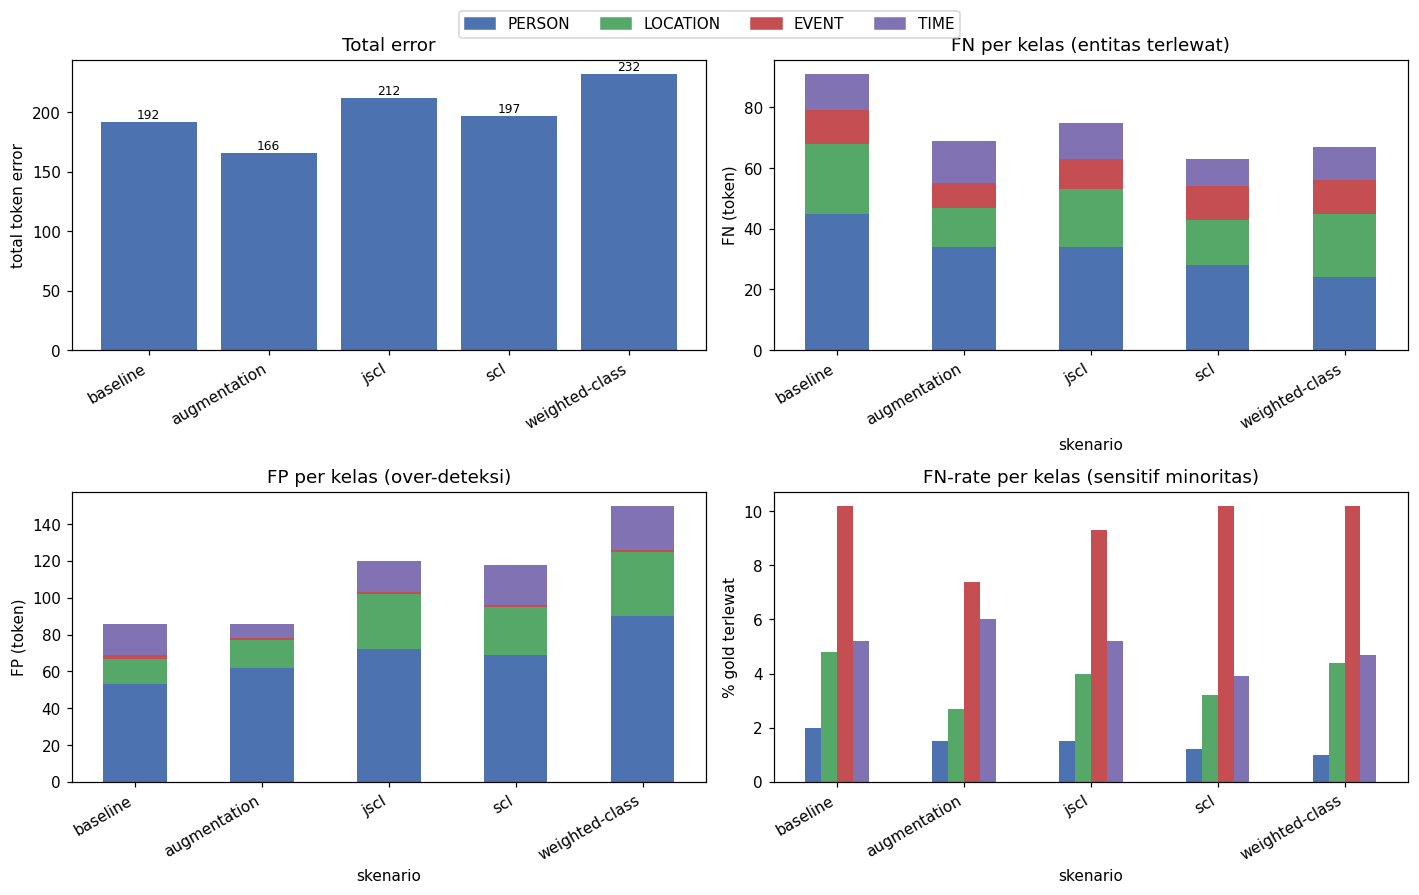

disimpan: s1_compare.png


In [11]:
_ = analyze_group('S1 - Handle Imbalance', GROUPS['S1 - Handle Imbalance'])

## S2 — Model Comparison

Backbone berbeda dengan pipeline sama: `baseline` (IndoBERT uncased) vs `cahya-bert-base` (uncased), `distilbert` (uncased), `indobert-base-p1` (cased), `roberta`. Perhatikan apakah ada anomali (total error melonjak).

S2 - Model Comparison


,total_error,error_%,FN_PERSON,FN_LOCATION,FN_EVENT,FN_TIME,FP_PERSON,FP_LOCATION,FP_EVENT,FP_TIME,FNrate_PERSON_%,FNrate_LOCATION_%,FNrate_EVENT_%,FNrate_TIME_%
skenario,,,,,,,,,,,,,,
baseline,192,0.451,45,23,11,12,53,14,2,17,2.0,4.8,10.2,5.2
cahya-bert-base,243,0.571,35,24,11,12,96,19,3,26,1.5,5.1,10.2,5.2
distilbert,216,0.508,17,18,10,14,90,22,1,29,0.7,3.8,9.3,6.0
indobert-base-p1,721,1.694,172,40,19,31,239,20,8,55,7.5,8.4,17.6,13.4
roberta,641,1.506,163,30,16,27,181,24,6,49,7.1,6.3,14.8,11.6


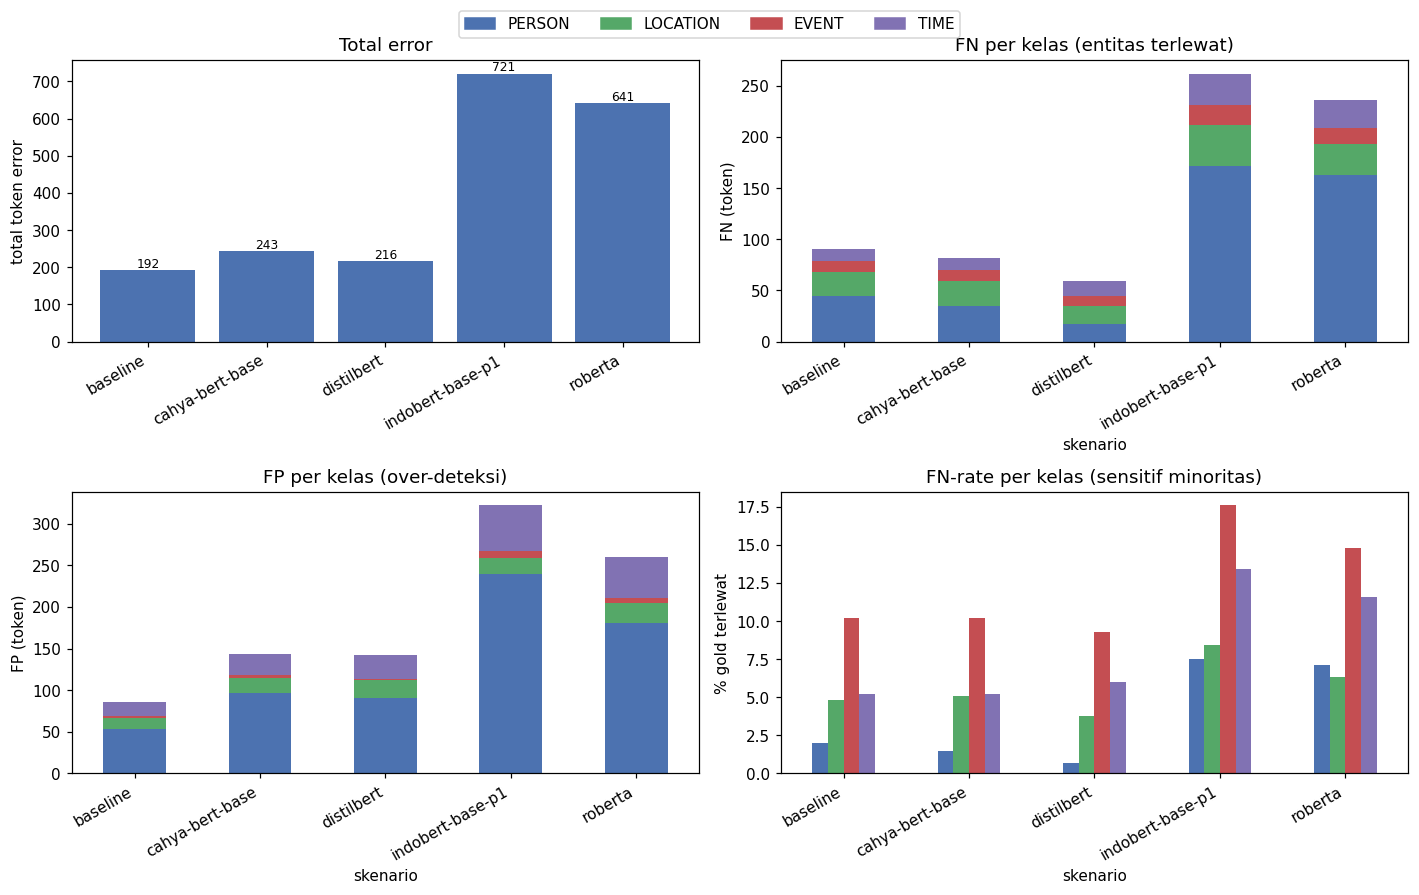

disimpan: s2_compare.png


In [12]:
_ = analyze_group('S2 - Model Comparison', GROUPS['S2 - Model Comparison'])

## S3 — POS-tag Module

Pengaruh penambahan fitur POS-tag: `baseline` vs `pos-tag`.

S3 - POS-tag Module


,total_error,error_%,FN_PERSON,FN_LOCATION,FN_EVENT,FN_TIME,FP_PERSON,FP_LOCATION,FP_EVENT,FP_TIME,FNrate_PERSON_%,FNrate_LOCATION_%,FNrate_EVENT_%,FNrate_TIME_%
skenario,,,,,,,,,,,,,,
baseline,192,0.451,45,23,11,12,53,14,2,17,2.0,4.8,10.2,5.2
pos-tag,224,0.526,25,17,10,10,87,30,1,28,1.1,3.6,9.3,4.3


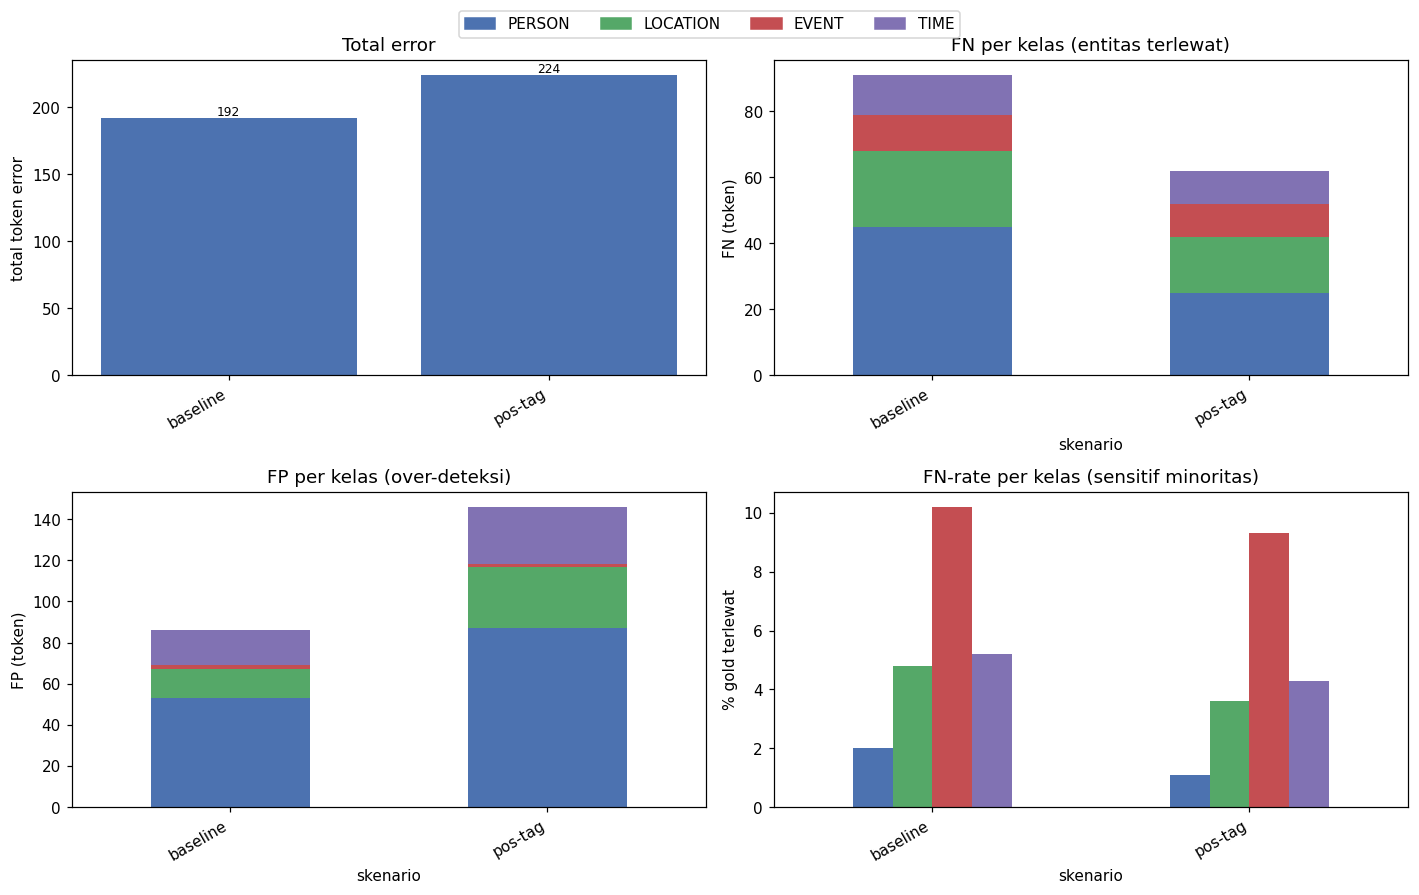

disimpan: s3_compare.png


In [13]:
_ = analyze_group('S3 - POS-tag Module', GROUPS['S3 - POS-tag Module'])

## Confusion matrix per skenario (opsional, semua grup)

Untuk memastikan error didominasi **deteksi** (ke/dari `O`), bukan salah tipe antar-entitas.

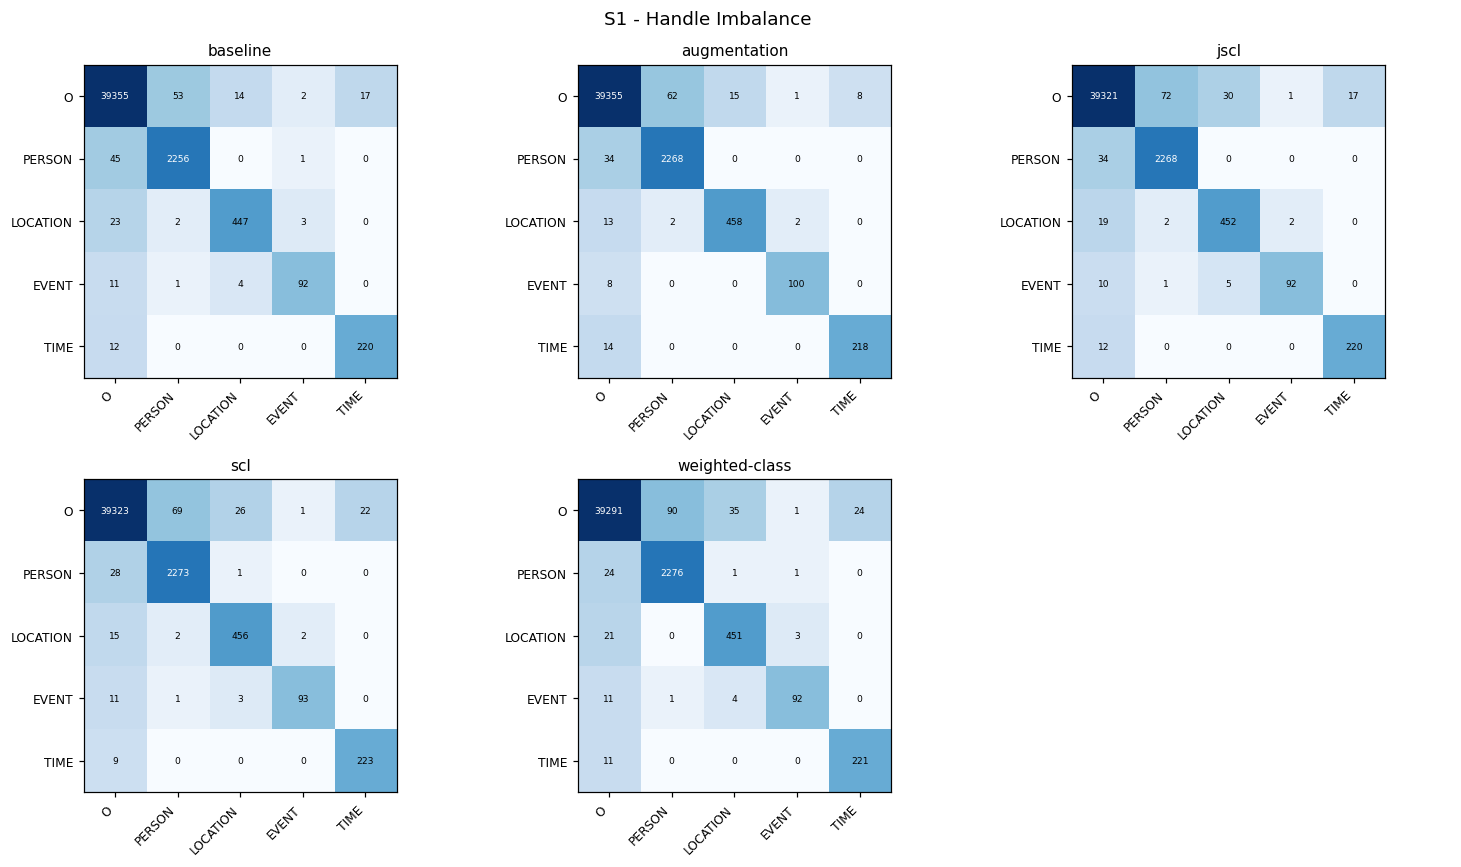

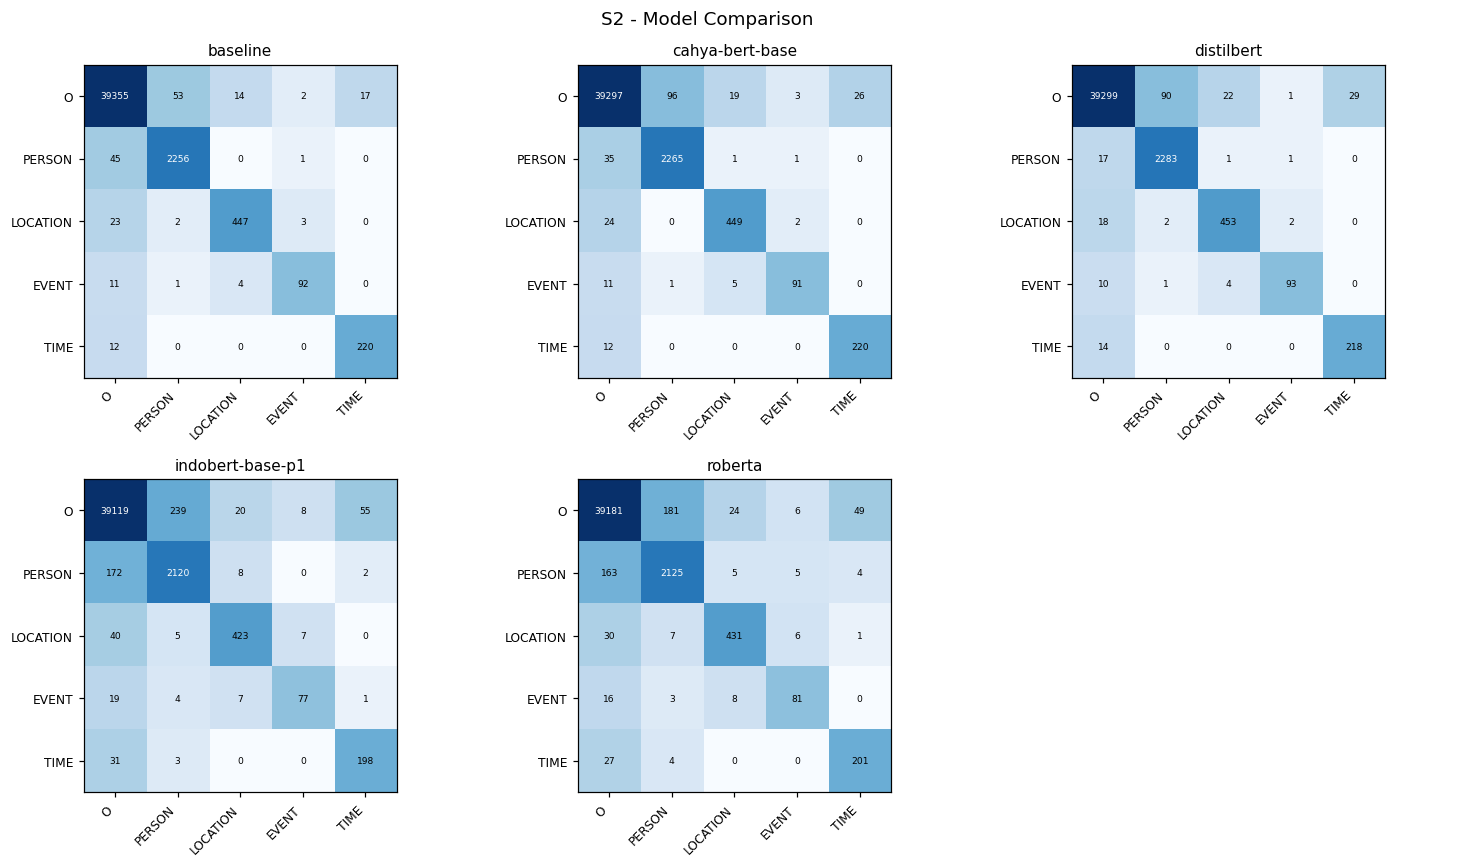

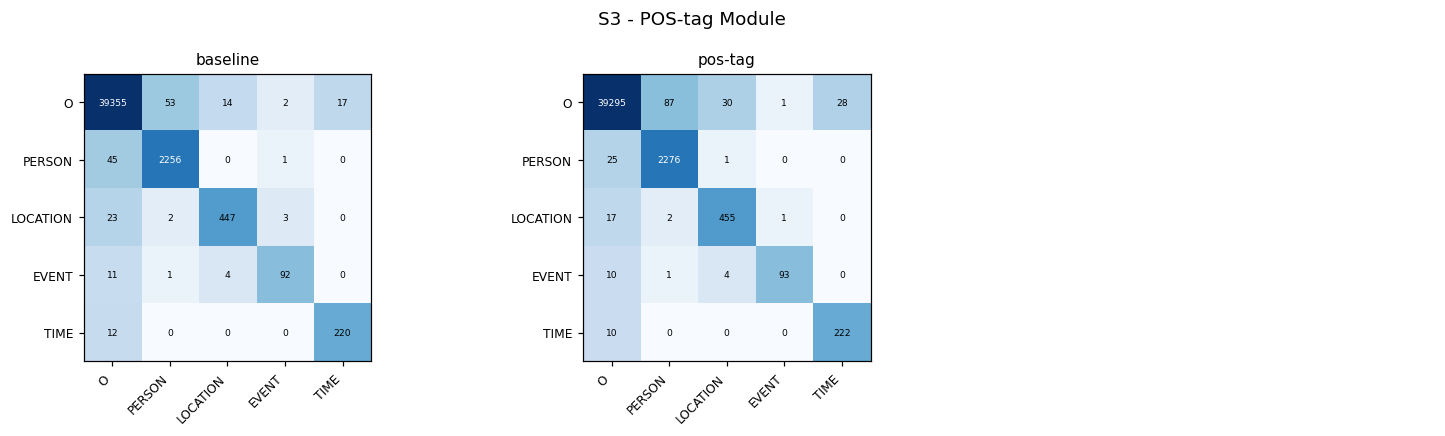

In [14]:
def confusion_grid(scns, ncol=3, title=''):
    order = ['O'] + LABELS
    nrow = int(np.ceil(len(scns) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.6*ncol, 4.0*nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[len(scns):]:
        ax.axis('off')
    for ax, nm in zip(axes, scns):
        d = RAW[nm]
        cm = pd.crosstab(d['gtype'], d['ptype']).reindex(index=order, columns=order).fillna(0).astype(int)
        ax.imshow(np.log10(cm.values + 1), cmap='Blues')
        ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
        ax.set_title(nm, fontsize=10)
        mx = np.log10(cm.values.max() + 1)
        for i in range(len(order)):
            for j in range(len(order)):
                v = cm.values[i, j]
                ax.text(j, i, f'{v}', ha='center', va='center', fontsize=6,
                        color='white' if np.log10(v+1) > mx*0.6 else 'black')
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT / (title.split(' ')[0].lower() + '_confusion.png'), bbox_inches='tight')
    plt.show()

for g, scns in GROUPS.items():
    confusion_grid(scns, title=g)

## Contoh kesalahan ber-highlight dalam konteks (FP & FN & misklasifikasi)

Menampilkan token yang salah, di-highlight di dalam teks chunk asli (kolom `text`), lengkap dengan label gold vs prediksi. Bisa dipilih skenario dan kategori error apa saja:
- `'FP'` = over-deteksi (kata biasa `O` salah ditandai sebagai entitas)
- `'FN'` = entitas terlewat (jadi `O`)
- `'MIS'` = misklasifikasi tipe (jenis entitas salah)
- `'BND'` = boundary (batas B/I salah)

Bagus untuk screenshot Bab 4. Ganti argumen `show_errors(...)` untuk skenario/kategori lain.

In [15]:
from IPython.display import HTML, display

BADGE = {'FN': '#C44E52', 'FP': '#DD8452', 'MIS': '#8172B3', 'BND': '#937860'}
CATNAME = {'FN': 'FN (terlewat)', 'FP': 'FP (over-deteksi)',
           'MIS': 'Misklasifikasi tipe', 'BND': 'Boundary B/I'}
_norm = lambda s: re.sub(r'[^0-9A-Za-z]', '', str(s)).lower()


def _context(token, text, window=8):
    """Cari token di teks chunk, kembalikan window kata + posisi token (untuk highlight)."""
    words = str(text).split()
    tn = _norm(token)
    pos = next((k for k, wd in enumerate(words) if _norm(wd) == tn), None)
    if pos is None:
        pos = next((k for k, wd in enumerate(words) if tn and tn in _norm(wd)), None)
    if pos is None:
        return None, None
    lo, hi = max(0, pos - window), min(len(words), pos + window + 1)
    return words, (lo, pos, hi)


def show_errors(scenario, category, n=6, window=8, seed=0):
    """Tampilkan n contoh error (kategori FP/FN/MIS/BND) skenario tertentu, token di-highlight."""
    d = RAW[scenario]
    err = d[d['ecat'] == category]
    color = BADGE.get(category, '#333')
    head = (f'<h4 style="margin:6px 0">{scenario} &mdash; {CATNAME.get(category, category)} '
            f'<span style="font-weight:normal;color:#888">({len(err)} token)</span></h4>')
    if err.empty:
        display(HTML(head + '<i>tidak ada error kategori ini.</i>')); return
    html = [head]
    for _, r in err.sample(min(n, len(err)), random_state=seed).iterrows():
        words, span = _context(r['token'], r['text'], window)
        if words is None:
            ctx = f"…{r['token']}…"
        else:
            lo, pos, hi = span
            ctx = ' '.join(
                f'<mark style="background:{color};color:white;padding:1px 4px;border-radius:3px;font-weight:bold">{words[k]}</mark>'
                if k == pos else words[k] for k in range(lo, hi))
        html.append(
            f'<div style="margin:6px 0;padding:6px 10px;border-left:3px solid {color};'
            f'background:#fafafa;font-size:13px">…{ctx}…<br>'
            f'<span style="color:#666;font-size:11px">token=<b>{r["token"]}</b> &nbsp; '
            f'gold=<b>{r["gold"]}</b> &nbsp; pred=<b>{r["pred"]}</b> &nbsp; chunk={r["text_id"]}</span></div>')
    display(HTML('\n'.join(html)))


# Demo: baseline & augmentation (winner) — FP dan FN
show_errors('baseline', 'FP', n=6)
show_errors('baseline', 'FN', n=6)
show_errors('augmentation', 'FP', n=6)
show_errors('augmentation', 'FN', n=6)

## Ringkasan semua skenario

In [16]:
ringkas = METRICS[['total_error', 'error_%', 'FN_PERSON', 'FN_LOCATION', 'FN_EVENT', 'FN_TIME',
                   'FNrate_EVENT_%', 'FNrate_TIME_%']].sort_values('total_error')
ringkas.to_csv(OUT / 'ringkasan_per_grup.csv')
print('disimpan:', OUT / 'ringkasan_per_grup.csv')
ringkas

disimpan: e:\2_Kehidupan-Kuliah\10_tugas-akhir\repo-TA\TA_preprocess\TA_sirah\data\result\analysis\error_viz\by_group\ringkasan_per_grup.csv


,total_error,error_%,FN_PERSON,FN_LOCATION,FN_EVENT,FN_TIME,FNrate_EVENT_%,FNrate_TIME_%
skenario,,,,,,,,
augmentation,166,0.390,34,13,8,14,7.4,6.0
baseline,192,0.451,45,23,11,12,10.2,5.2
scl,197,0.463,28,15,11,9,10.2,3.9
jscl,212,0.498,34,19,10,12,9.3,5.2
distilbert,216,0.508,17,18,10,14,9.3,6.0
pos-tag,224,0.526,25,17,10,10,9.3,4.3
weighted-class,232,0.545,24,21,11,11,10.2,4.7
cahya-bert-base,243,0.571,35,24,11,12,10.2,5.2
roberta,641,1.506,163,30,16,27,14.8,11.6
